<a href="https://colab.research.google.com/github/charleneshen3/applied_datascience_project4/blob/main/survival_analysis_extension.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Build survival dataset

In [1]:
# =========================
# Build survival dataset from Yahoo Finance
# Event = next large negative daily return
# =========================

!pip install yfinance lifelines pandas numpy matplotlib -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

stocks = ["AAPL", "NFLX", "MSFT", "AMZN"]
start = "2015-01-01"
end = "2026-04-01"

# Event threshold: large negative daily move
drop_threshold = -0.03  # -3%

def compute_rsi(close, window=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(close, fast=12, slow=26, signal=9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()

    return macd, macd_signal

def compute_obv(close, volume):
    direction = np.sign(close.diff()).fillna(0)
    return (direction * volume).cumsum()

def build_daily_features(ticker):
    raw = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False
    )

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    close = raw["Adj Close"]
    volume = raw["Volume"]

    df = pd.DataFrame(index=raw.index)
    df["ticker"] = ticker
    df["date"] = df.index
    df["AdjClose"] = close
    df["DailyReturn"] = close.pct_change()

    # Basic technical covariates
    df["RSI"] = compute_rsi(close, 14)

    macd, macd_signal = compute_macd(close)
    df["MACD"] = macd
    df["MACDSignal"] = macd_signal

    df["PriceROC"] = close.pct_change(14) * 100
    df["OBV"] = compute_obv(close, volume)

    df["RollingVolatility_7"] = df["DailyReturn"].rolling(7).std()
    df["RollingVolatility_21"] = df["DailyReturn"].rolling(21).std()

    weekly_mean = close.rolling(7).mean()
    quarterly_mean = close.rolling(90).mean()
    annual_mean = close.rolling(252).mean()

    df["WeeklyMeanRatio"] = weekly_mean / close
    df["QuarterlyRatio"] = quarterly_mean / close
    df["AnnualRatio"] = annual_mean / close

    # Event indicator for that day
    df["large_drop_event"] = (df["DailyReturn"] <= drop_threshold).astype(int)

    df = df.dropna().copy()
    return df

# Build panel of daily features
daily_panel = pd.concat(
    [build_daily_features(ticker) for ticker in stocks],
    ignore_index=True
)

print("Daily panel shape:", daily_panel.shape)

print("Large-drop event counts:")
display(
    daily_panel
    .groupby("ticker")["large_drop_event"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "event_count", "count": "n_days", "mean": "event_rate"})
    .round(4)
)

display(daily_panel.head())

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.6 MB/s eta 0:00:00
Daily panel shape: (10304, 15)
Large-drop event counts:


,event_count,n_days,event_rate
ticker,,,
AAPL,108,2576,0.0419
AMZN,144,2576,0.0559
MSFT,88,2576,0.0342
NFLX,192,2576,0.0745


,ticker,date,AdjClose,DailyReturn,RSI,MACD,MACDSignal,PriceROC,OBV,RollingVolatility_7,RollingVolatility_21,WeeklyMeanRatio,QuarterlyRatio,AnnualRatio,large_drop_event
0,AAPL,2015-12-31,23.710670,-0.019195,24.988479,-0.580180,-0.495253,-9.391413,-2.001060e+09,0.013733,0.015615,1.020616,1.077931,1.131119,0
1,AAPL,2016-01-04,23.730940,0.000855,29.296476,-0.595724,-0.515347,-6.918240,-1.730462e+09,0.013788,0.015638,1.017195,1.077227,1.130072,0
2,AAPL,2016-01-05,23.136267,-0.025059,26.570646,-0.648551,-0.541988,-8.685992,-1.953626e+09,0.014214,0.016242,1.035133,1.104210,1.159050,0
3,AAPL,2016-01-06,22.683496,-0.019570,26.545183,-0.718668,-0.577324,-8.860534,-2.227456e+09,0.014799,0.013890,1.045396,1.124955,1.182036,0
4,AAPL,2016-01-07,21.726147,-0.042205,19.324240,-0.841782,-0.630216,-13.373444,-2.551833e+09,0.019231,0.015773,1.076102,1.172642,1.233731,1


# Convert data into survival spells (right censoring)

In [2]:
# =========================
# Convert daily stock data into survival spells
# Each spell = time until next large negative return
# =========================

covariates = [
    "RSI",
    "MACD",
    "MACDSignal",
    "PriceROC",
    "OBV",
    "RollingVolatility_7",
    "RollingVolatility_21",
    "WeeklyMeanRatio",
    "QuarterlyRatio",
    "AnnualRatio"
]

survival_rows = []

for ticker in stocks:
    df = daily_panel[daily_panel["ticker"] == ticker].sort_values("date").reset_index(drop=True)

    # Event days
    event_indices = df.index[df["large_drop_event"] == 1].tolist()

    # Start a spell at the first usable row, then after each event
    spell_starts = [0] + [idx + 1 for idx in event_indices if idx + 1 < len(df)]

    for start_idx in spell_starts:
        future_events = [idx for idx in event_indices if idx >= start_idx]

        if len(future_events) > 0:
            event_idx = future_events[0]
            duration = event_idx - start_idx + 1
            event_observed = 1
        else:
            event_idx = len(df) - 1
            duration = event_idx - start_idx + 1
            event_observed = 0

        # Use covariates measured at the start of the spell
        row = {
            "ticker": ticker,
            "start_date": df.loc[start_idx, "date"],
            "end_date": df.loc[event_idx, "date"],
            "duration": duration,
            "event": event_observed
        }

        for c in covariates:
            row[c] = df.loc[start_idx, c]

        survival_rows.append(row)

survival_df = pd.DataFrame(survival_rows)

print("Survival dataset shape:", survival_df.shape)
print("Event/censoring summary:")
display(survival_df.groupby("ticker")["event"].agg(["sum", "count", "mean"]).round(4))

display(survival_df.head())

Survival dataset shape: (536, 15)
Event/censoring summary:


,sum,count,mean
ticker,,,
AAPL,108,109,0.9908
AMZN,144,145,0.9931
MSFT,88,89,0.9888
NFLX,192,193,0.9948


,ticker,start_date,end_date,duration,event,RSI,MACD,MACDSignal,PriceROC,OBV,RollingVolatility_7,RollingVolatility_21,WeeklyMeanRatio,QuarterlyRatio,AnnualRatio
0,AAPL,2015-12-31,2016-01-07,5,1,24.988479,-0.580180,-0.495253,-9.391413,-2.001060e+09,0.013733,0.015615,1.020616,1.077931,1.131119
1,AAPL,2016-01-08,2016-01-27,13,1,23.193542,-0.919482,-0.688069,-11.029562,-2.268641e+09,0.016008,0.015986,1.053085,1.164718,1.226708
2,AAPL,2016-01-28,2016-04-27,63,1,45.560589,-0.753348,-0.779701,-2.446852,-2.275571e+09,0.035493,0.025341,1.034648,1.178112,1.258195
3,AAPL,2016-04-28,2016-04-28,1,1,17.304781,-0.325493,0.065067,-12.727774,-2.031864e+09,0.022712,0.017815,1.085943,1.075053,1.185567
4,AAPL,2016-04-29,2017-05-17,265,1,15.082154,-0.485366,-0.045019,-14.015775,-2.305990e+09,0.021380,0.017842,1.078165,1.086165,1.198120


# Fit Cox Model

## Baseline Model

In [4]:
# =========================
# Fit Cox proportional hazards model
# =========================

from lifelines import CoxPHFitter

cox_df = survival_df.copy()

# One-hot encode ticker fixed effects
cox_df = pd.get_dummies(cox_df, columns=["ticker"], drop_first=True)

# Keep only model columns
model_cols = ["duration", "event"] + covariates + [
    col for col in cox_df.columns if col.startswith("ticker_")
]

cox_model_df = cox_df[model_cols].copy()

# Standardize continuous covariates for interpretability/stability
for c in covariates:
    cox_model_df[c] = (
        cox_model_df[c] - cox_model_df[c].mean()
    ) / cox_model_df[c].std()

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_model_df, duration_col="duration", event_col="event")

cph.print_summary()

# Extract hazard ratios
hazard_ratios = cph.summary[["coef", "exp(coef)", "p"]].copy()
hazard_ratios = hazard_ratios.rename(columns={"exp(coef)": "hazard_ratio"})
hazard_ratios = hazard_ratios.sort_values("hazard_ratio", ascending=False)

display(hazard_ratios)

<lifelines.CoxPHFitter: fitted with 536 total observations, 4 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 536
number of events observed = 532
   partial log-likelihood = -2769.36
         time fit was run = 2026-04-25 05:14:05 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
RSI                   0.11      1.12      0.08           -0.04            0.26                0.96                1.30
MACD                 -0.09      0.91      0.09           -0.27            0.09                0.76                1.09
MACDSignal            0.02      1.02      0.09           -0.15            0.19                0.86                1.21
PriceROC             -0.17      0.85      0.09           -0.34            0.01                0.71                1.01
OBV                   0.10      1.10      0.06           -0.02            0.21                0.98                1.24
RollingVolatility_7   0.07      1.07      0.06           -0.04            0.18                0.96                1.20
RollingVolatility_21  0.19      1.21      0.06            0.07            0.32                1.07                1.38
WeeklyMeanRatio       0.14      1.15      0.05            0.04            0.24                1.04                1.27
QuarterlyRatio       -0.01      0.99      0.09           -0.18            0.16                0.84                1.17
AnnualRatio           0.04      1.04      0.07           -0.10            0.18                0.90                1.19
ticker_AMZN          -0.06      0.94      0.14           -0.34            0.22                0.71                1.24
ticker_MSFT          -0.11      0.89      0.14           -0.38            0.16                0.68                1.17
ticker_NFLX           0.11      1.12      0.11           -0.11            0.33                0.90                1.40

                      cmp to     z      p  -log2(p)
covariate                                          
RSI                     0.00  1.48   0.14      2.85
MACD                    0.00 -1.00   0.32      1.66
MACDSignal              0.00  0.19   0.85      0.24
PriceROC                0.00 -1.87   0.06      4.03
OBV                     0.00  1.61   0.11      3.22
RollingVolatility_7     0.00  1.19   0.23      2.10
RollingVolatility_21    0.00  3.05 <0.005      8.77
WeeklyMeanRatio         0.00  2.78   0.01      7.54
QuarterlyRatio          0.00 -0.14   0.89      0.16
AnnualRatio             0.00  0.52   0.60      0.74
ticker_AMZN             0.00 -0.43   0.67      0.59
ticker_MSFT             0.00 -0.82   0.41      1.27
ticker_NFLX             0.00  1.00   0.32      1.65
---
Concordance = 0.65
Partial AIC = 5564.72
log-likelihood ratio test = 91.91 on 13 df
-log2(p) of ll-ratio test = 43.92

,coef,hazard_ratio,p
covariate,,,
RollingVolatility_21,0.194004,1.214101,0.002298
WeeklyMeanRatio,0.141325,1.151799,0.005382
ticker_NFLX,0.112229,1.118769,0.319091
RSI,0.111420,1.117865,0.138970
OBV,0.096003,1.100763,0.107200
RollingVolatility_7,0.069616,1.072096,0.233662
AnnualRatio,0.037035,1.037730,0.600270
MACDSignal,0.017006,1.017151,0.845714
QuarterlyRatio,-0.011552,0.988515,0.892311


## Tuning penalizer to measure robustness

In [5]:
# =========================
# Cox model penalizer tuning by cross-validated concordance
# =========================

!pip install lifelines -q

import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.utils import k_fold_cross_validation

# Penalizer values to try
penalizers = [0.0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0]

tuning_rows = []

for pen in penalizers:
    cph_temp = CoxPHFitter(penalizer=pen)

    try:
        cv_scores = k_fold_cross_validation(
            cph_temp,
            cox_model_df,
            duration_col="duration",
            event_col="event",
            k=5,
            scoring_method="concordance_index"
        )

        tuning_rows.append({
            "penalizer": pen,
            "mean_cv_concordance": np.mean(cv_scores),
            "std_cv_concordance": np.std(cv_scores),
            "min_cv_concordance": np.min(cv_scores),
            "max_cv_concordance": np.max(cv_scores)
        })

    except Exception as e:
        tuning_rows.append({
            "penalizer": pen,
            "mean_cv_concordance": np.nan,
            "std_cv_concordance": np.nan,
            "min_cv_concordance": np.nan,
            "max_cv_concordance": np.nan
        })
        print(f"Penalizer {pen} failed: {e}")

cox_tuning_results = pd.DataFrame(tuning_rows).sort_values(
    "mean_cv_concordance",
    ascending=False
)

cox_tuning_results = cox_tuning_results.round(4)

print("Cox penalizer tuning results:")
display(cox_tuning_results)

# Select best penalizer
best_penalizer = cox_tuning_results.dropna().iloc[0]["penalizer"]

print(f"Best penalizer by mean CV concordance: {best_penalizer}")

# Refit final Cox model using best penalizer
cph_tuned = CoxPHFitter(penalizer=best_penalizer)
cph_tuned.fit(cox_model_df, duration_col="duration", event_col="event")

print("\nTuned Cox model summary:")
cph_tuned.print_summary()

# Extract tuned hazard ratios
tuned_hr = cph_tuned.summary[["coef", "exp(coef)", "p"]].copy()
tuned_hr = tuned_hr.rename(columns={"exp(coef)": "hazard_ratio"})
tuned_hr = tuned_hr.sort_values("hazard_ratio", ascending=False)

display(tuned_hr)

Cox penalizer tuning results:


,penalizer,mean_cv_concordance,std_cv_concordance,min_cv_concordance,max_cv_concordance
8,1.000,0.6439,0.0130,0.6303,0.6655
6,0.250,0.6421,0.0175,0.6143,0.6622
7,0.500,0.6416,0.0207,0.6130,0.6721
2,0.005,0.6400,0.0343,0.5857,0.6795
3,0.010,0.6385,0.0139,0.6191,0.6545
5,0.100,0.6384,0.0180,0.6183,0.6607
4,0.050,0.6297,0.0404,0.5592,0.6753
1,0.001,0.6254,0.0325,0.5670,0.6642
0,0.000,0.6218,0.0380,0.5535,0.6685


Best penalizer by mean CV concordance: 1.0

Tuned Cox model summary:


<lifelines.CoxPHFitter: fitted with 536 total observations, 4 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 1.0
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 536
number of events observed = 532
   partial log-likelihood = -2783.75
         time fit was run = 2026-04-25 05:14:19 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
RSI                   0.01      1.01      0.03           -0.06            0.07                0.94                1.08
MACD                 -0.03      0.97      0.04           -0.10            0.04                0.90                1.04
MACDSignal           -0.02      0.98      0.04           -0.09            0.05                0.92                1.05
PriceROC             -0.06      0.94      0.04           -0.13            0.01                0.88                1.01
OBV                   0.04      1.04      0.03           -0.03            0.10                0.97                1.11
RollingVolatility_7   0.09      1.09      0.03            0.02            0.15                1.02                1.16
RollingVolatility_21  0.11      1.11      0.04            0.04            0.18                1.04                1.19
WeeklyMeanRatio       0.08      1.08      0.03            0.01            0.15                1.01                1.16
QuarterlyRatio        0.04      1.04      0.04           -0.03            0.12                0.97                1.12
AnnualRatio           0.04      1.04      0.04           -0.03            0.11                0.97                1.11
ticker_AMZN           0.01      1.01      0.08           -0.14            0.16                0.87                1.17
ticker_MSFT          -0.10      0.91      0.09           -0.26            0.07                0.77                1.07
ticker_NFLX           0.08      1.09      0.07           -0.05            0.22                0.95                1.24

                      cmp to     z      p  -log2(p)
covariate                                          
RSI                     0.00  0.17   0.86      0.21
MACD                    0.00 -0.93   0.35      1.51
MACDSignal              0.00 -0.53   0.59      0.75
PriceROC                0.00 -1.57   0.12      3.10
OBV                     0.00  1.11   0.27      1.90
RollingVolatility_7     0.00  2.50   0.01      6.35
RollingVolatility_21    0.00  3.05 <0.005      8.76
WeeklyMeanRatio         0.00  2.36   0.02      5.79
QuarterlyRatio          0.00  1.17   0.24      2.06
AnnualRatio             0.00  1.03   0.30      1.72
ticker_AMZN             0.00  0.13   0.90      0.15
ticker_MSFT             0.00 -1.12   0.26      1.93
ticker_NFLX             0.00  1.22   0.22      2.17
---
Concordance = 0.65
Partial AIC = 5593.49
log-likelihood ratio test = 63.14 on 13 df
-log2(p) of ll-ratio test = 26.06

,coef,hazard_ratio,p
covariate,,,
RollingVolatility_21,0.106702,1.112603,0.002309
RollingVolatility_7,0.085656,1.089431,0.012283
ticker_NFLX,0.083538,1.087127,0.222817
WeeklyMeanRatio,0.079976,1.083261,0.018034
QuarterlyRatio,0.043837,1.044812,0.240351
OBV,0.036890,1.037579,0.267158
AnnualRatio,0.036577,1.037254,0.303474
ticker_AMZN,0.009636,1.009683,0.899574
RSI,0.005991,1.006009,0.863150


## Visualization: Forest Plot

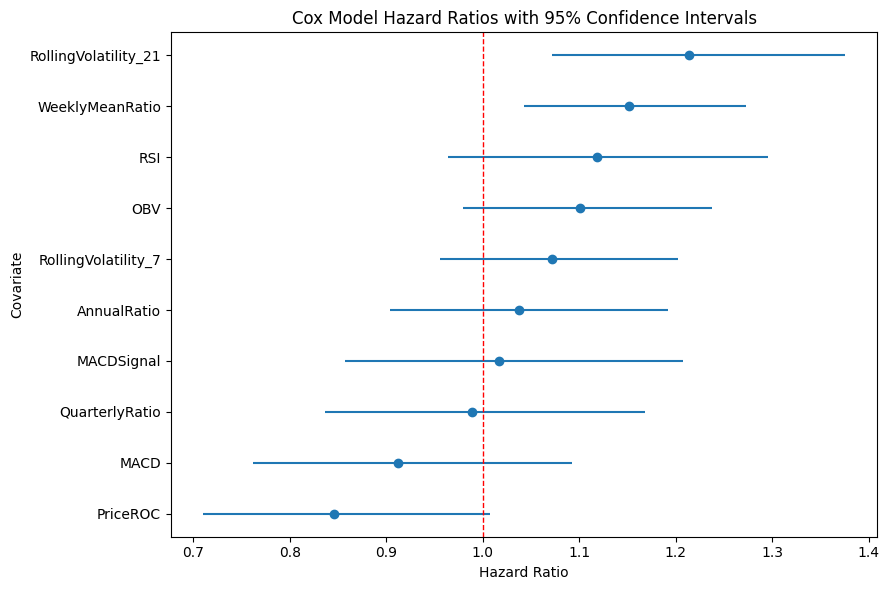

In [ ]:
# =========================
# Forest plot of Cox model hazard ratios
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pull summary table from fitted Cox model
hr_df = cph.summary.copy()

# Keep a cleaner set of columns
hr_df = hr_df[[
    "coef",
    "exp(coef)",
    "exp(coef) lower 95%",
    "exp(coef) upper 95%",
    "p"
]].copy()

hr_df = hr_df.rename(columns={
    "exp(coef)": "hazard_ratio",
    "exp(coef) lower 95%": "hr_lower",
    "exp(coef) upper 95%": "hr_upper"
})

# Remove ticker dummies to focus on technical indicators only
hr_df = hr_df[~hr_df.index.str.startswith("ticker_")].copy()

# Sort by hazard ratio
hr_df = hr_df.sort_values("hazard_ratio")

# Plot
y_pos = np.arange(len(hr_df))

plt.figure(figsize=(9, 6))
plt.errorbar(
    hr_df["hazard_ratio"],
    y_pos,
    xerr=[
        hr_df["hazard_ratio"] - hr_df["hr_lower"],
        hr_df["hr_upper"] - hr_df["hazard_ratio"]
    ],
    fmt="o"
)

plt.axvline(1.0, linestyle="--", linewidth=1, color = 'red')
plt.yticks(y_pos, hr_df.index)
plt.xlabel("Hazard Ratio")
plt.ylabel("Covariate")
plt.title("Cox Model Hazard Ratios with 95% Confidence Intervals")
plt.tight_layout()
plt.show()

# Kaplan-Meier Survival Curve

Counts by risk group:


,count
risk_group,
Low risk,179
High risk,179
Medium risk,178


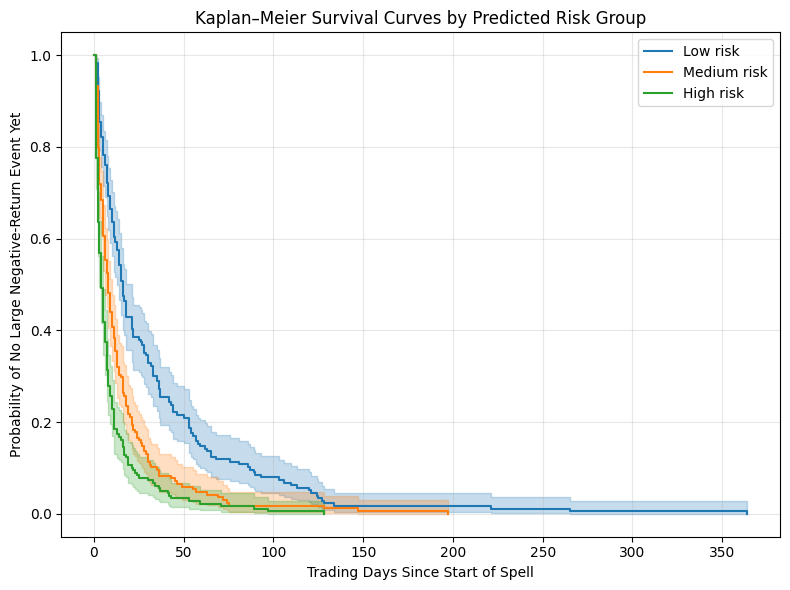

In [ ]:
# =========================
# Kaplan-Meier curves by Cox-predicted risk group
# =========================

from lifelines import KaplanMeierFitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Copy original survival data
km_df = survival_df.copy().reset_index(drop=True)

# Get Cox predicted partial hazard for each observation
km_df["predicted_risk"] = np.asarray(cph.predict_partial_hazard(cox_model_df)).reshape(-1)

# Split into 3 groups: low / medium / high predicted risk
km_df["risk_group"] = pd.qcut(
    km_df["predicted_risk"],
    q=3,
    labels=["Low risk", "Medium risk", "High risk"],
    duplicates="drop"
)

print("Counts by risk group:")
display(km_df["risk_group"].value_counts(dropna=False))

# Plot Kaplan-Meier curves
plt.figure(figsize=(8, 6))
kmf = KaplanMeierFitter()

for group in ["Low risk", "Medium risk", "High risk"]:
    group_df = km_df[km_df["risk_group"] == group]
    if len(group_df) == 0:
        continue

    kmf.fit(
        durations=group_df["duration"],
        event_observed=group_df["event"],
        label=group
    )
    kmf.plot_survival_function()

plt.title("Kaplan–Meier Survival Curves by Predicted Risk Group")
plt.xlabel("Trading Days Since Start of Spell")
plt.ylabel("Probability of No Large Negative-Return Event Yet")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Log-rank test + median survival by risk group
# =========================

from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
from lifelines import KaplanMeierFitter
import pandas as pd
import numpy as np

# Overall log-rank test across low / medium / high risk groups
logrank_result = multivariate_logrank_test(
    event_durations=km_df["duration"],
    groups=km_df["risk_group"],
    event_observed=km_df["event"]
)

print("Overall log-rank test across risk groups:")
logrank_result.print_summary()

# Pairwise log-rank tests
pairwise_results = pairwise_logrank_test(
    event_durations=km_df["duration"],
    groups=km_df["risk_group"],
    event_observed=km_df["event"]
)

print("\nPairwise log-rank tests:")
pairwise_results.print_summary()

# Median survival time by group
kmf = KaplanMeierFitter()
summary_rows = []

for group in ["Low risk", "Medium risk", "High risk"]:
    group_df = km_df[km_df["risk_group"] == group].copy()

    kmf.fit(
        durations=group_df["duration"],
        event_observed=group_df["event"],
        label=group
    )

    summary_rows.append({
        "risk_group": group,
        "n_spells": len(group_df),
        "n_events": int(group_df["event"].sum()),
        "event_rate": group_df["event"].mean(),
        "median_survival_days": kmf.median_survival_time_,
        "mean_predicted_risk": group_df["predicted_risk"].mean()
    })

km_summary = pd.DataFrame(summary_rows)

km_summary["event_rate"] = km_summary["event_rate"].round(4)
km_summary["mean_predicted_risk"] = km_summary["mean_predicted_risk"].round(4)

print("\nKaplan-Meier summary by risk group:")
display(km_summary)

Overall log-rank test across risk groups:



Pairwise log-rank tests:



Kaplan-Meier summary by risk group:


,risk_group,n_spells,n_events,event_rate,median_survival_days,mean_predicted_risk
0,Low risk,179,178,0.9944,16.0,0.6876
1,Medium risk,178,175,0.9831,8.0,0.9277
2,High risk,179,179,1.0000,4.0,1.9097
